# EEG During mental arithmetic

This data has been extracted from https://physionet.org/content/eegmat/1.0.0/
Original publication: https://physionet.org/content/eegmat/1.0.0/

Other EEG data can be found here: https://openneuro.org/

We will use this dataset to showcase the MESA pipeline, utilizing PCA, MSPC and ASCA as the analysis tools

In [355]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Initial raw data exploration

In [356]:
subject_info = pd.read_csv("../data/EEG/subject-info.csv")
subject_info.head() # ---> Get classes for MEDA visualization from here.

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [357]:
subject_info[subject_info["Gender"]=="M"].count()

Subject                   9
Age                       9
Gender                    9
Recording year            9
Number of subtractions    9
Count quality             9
dtype: int64

In [358]:
subject_ids             = subject_info["Subject"].to_numpy(dtype=str)
subject_ages            = subject_info["Age"].to_numpy(dtype=int)
subject_genders         = subject_info["Gender"].to_numpy(dtype=str)
subject_rec_years       = subject_info["Recording year"].to_numpy(dtype=int)
subject_n_subtractions  = subject_info["Number of subtractions"].to_numpy(dtype=float)
subject_quality         = subject_info["Count quality"].to_numpy(dtype=int)
operations = [1, 2]
operation_labels = ["Baseline", "Arithmetic"]

In [359]:
subject_id = subject_ids[10]
operation = operations[0]
file = f"../data/EEG/{subject_id}_{operation}.edf"
data = mne.io.read_raw_edf(file)
raw_data = data.get_data()[:, 0:]
info = data.info
channels = data.ch_names

Extracting EDF parameters from ../data/EEG/Subject10_1.edf...
Setting channel info structure...
Creating raw.info structure...


In [360]:
print(f"There are:\n - {len(subject_ids)} subjects. \n - {len(channels)} channels. \nSampling rate: 500.0Hz")

There are:
 - 36 subjects. 
 - 21 channels. 
Sampling rate: 500.0Hz


#### See signals

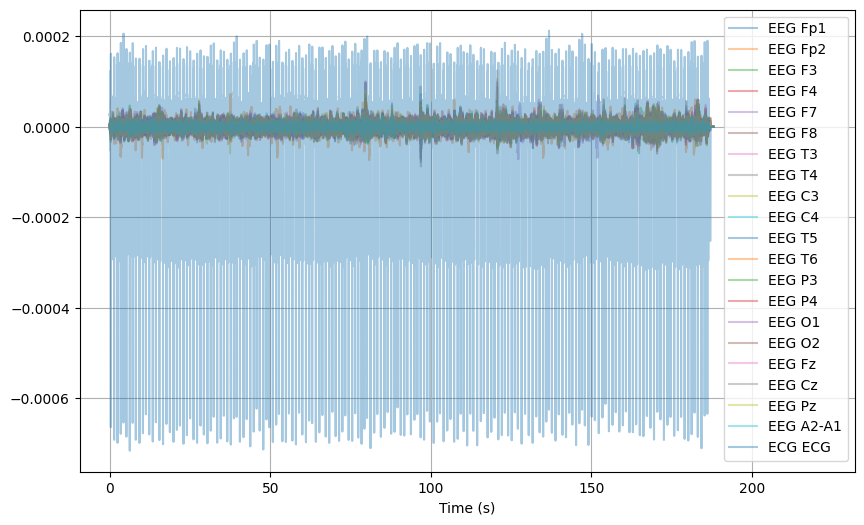

In [361]:
test_signal = raw_data[:, :].T
time = np.linspace(0, test_signal.shape[0]/500, test_signal.shape[0])
fig, ax = plt.subplots(1,1, figsize=(10,6))
# fig.suptitle(f"{subject_id} - Operation: {operation_labels[operation]}")
ax.plot(time, test_signal, label=channels, alpha=0.4)
ax.grid(True)
ax.legend()
ax.set_xlabel("Time (s)");
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], xlim[1]*1.175);
# ax.set_xlim(182, 195);


#### Read signals

In [362]:
Y = np.full((len(subject_ids), len(operations), len(channels), int(1e5)), np.nan)

for i, operation in enumerate(operations[:]):
    for j, subject_id in enumerate(subject_ids[:]):
            file = f"../data/EEG/{subject_id}_{operation}.edf"
            data = mne.io.read_raw_edf(file, verbose=False)
            aux = data.get_data()[:, :]
            last_id = aux.shape[-1]-1000
            Y[j,i,:, 0:last_id] = aux[:, 0:last_id] # Quitamos los últimos segundos, que son artificios.


mask = ~np.isnan(Y).any(axis=(0, 1, 2))
Y = Y[:, :, :, mask]
print(f"Signal tensor dimension: {Y.shape}\n")

Signal tensor dimension: (36, 2, 21, 30000)



#### STFT feature extraction

In [363]:
from mesa.features import stft, stft_labels
import librosa
# A high-pass filter with 0.5 Hz cut-off frequency, low-pass filter with 45 Hz cut-off frequency and a power line notch filter (50 Hz) were used
# We are looking at frequencies in the range: [0.5, 45] Hz

# Downsample
sr = 500
Y = librosa.resample(Y, orig_sr = 500, target_sr = 100)

# STFT params
sr = 100
window_length = int(1.00*sr)
n_fft = window_length
hop = window_length//4
window = "blackman"
n_bins = window_length
center = True

D = stft(Y,window_length,hop, center=center, n_fft = n_fft)
Sxx = np.abs(D)**2
Sxx = librosa.amplitude_to_db(np.abs(D))

times, freqs = stft_labels(D, sr, hop, n_fft = n_fft)

print(f"Sxx.shape: {Sxx.shape}")
print(f"dimensions: (subject, operation, channel, freqs, times")

Sxx.shape: (36, 2, 21, 51, 241)
dimensions: (subject, operation, channel, freqs, times


#### Correct for filters
A high-pass filter with 0.5 Hz cut-off frequency

low-pass filter with 45 Hz cut-off frequency 

and a power line notch filter (50 Hz) were used

In [364]:
### Eliminate filtered frequencies
# A high-pass filter with 0.5 Hz cut-off frequency, low-pass filter with 45 Hz cut-off frequency and a power line notch filter (50 Hz) were used
mask = np.ones(len(freqs), dtype=bool)

mask[freqs > 45.0] = False
mask[freqs <  0.5] = False
# id_50Hz = np.argmin(np.abs(freqs - 50.0))
# mask[id_50Hz] = False


freqs = freqs[mask]
Sxx = Sxx[:,:,:, mask, :]
n_frequencies = len(freqs)
print(f"Nº of frequencies after  masking the filter: {n_frequencies}")

Nº of frequencies after  masking the filter: 45


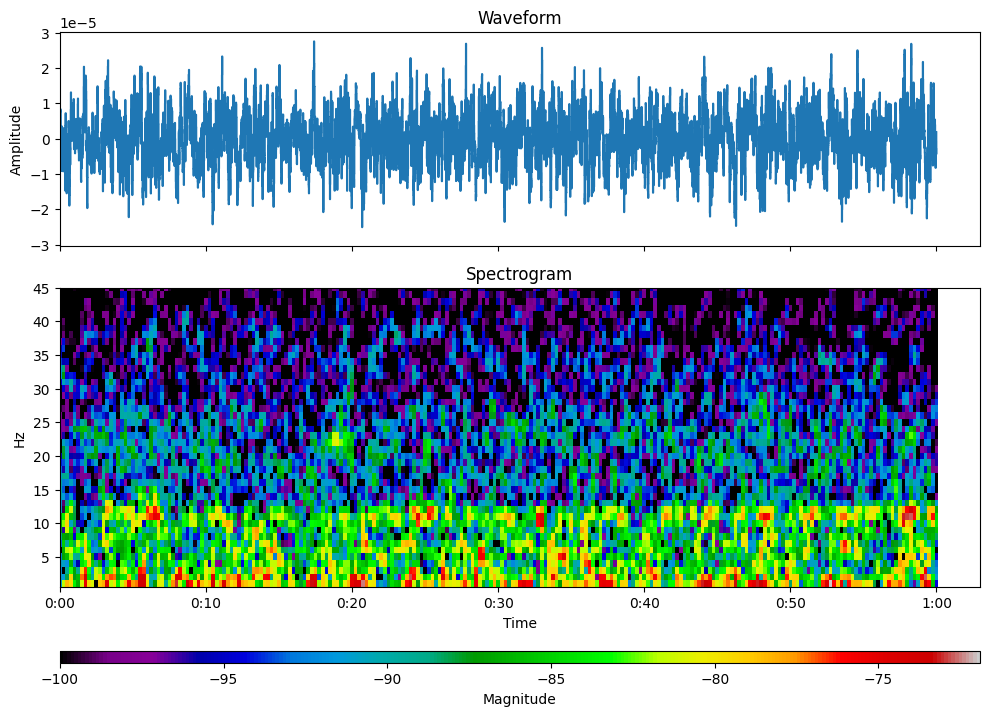

In [369]:
from mesa.visualization import plot_signal, dual_plot, spectrogram, multi_spectrogram
subject_id = 19
operation_id = 1
channel_id = 3
ids = (subject_id, operation_id, channel_id)


fig = dual_plot(Y[*ids], Sxx[*ids],sr,window_length,hop, n_fft=n_fft,
                center=center, cmap="nipy_spectral", y_coords=freqs);
ax = fig.get_axes()
ax[1].set_ylim(0.5,45);

dimensions: (subject, operation, channel, freqs, times)


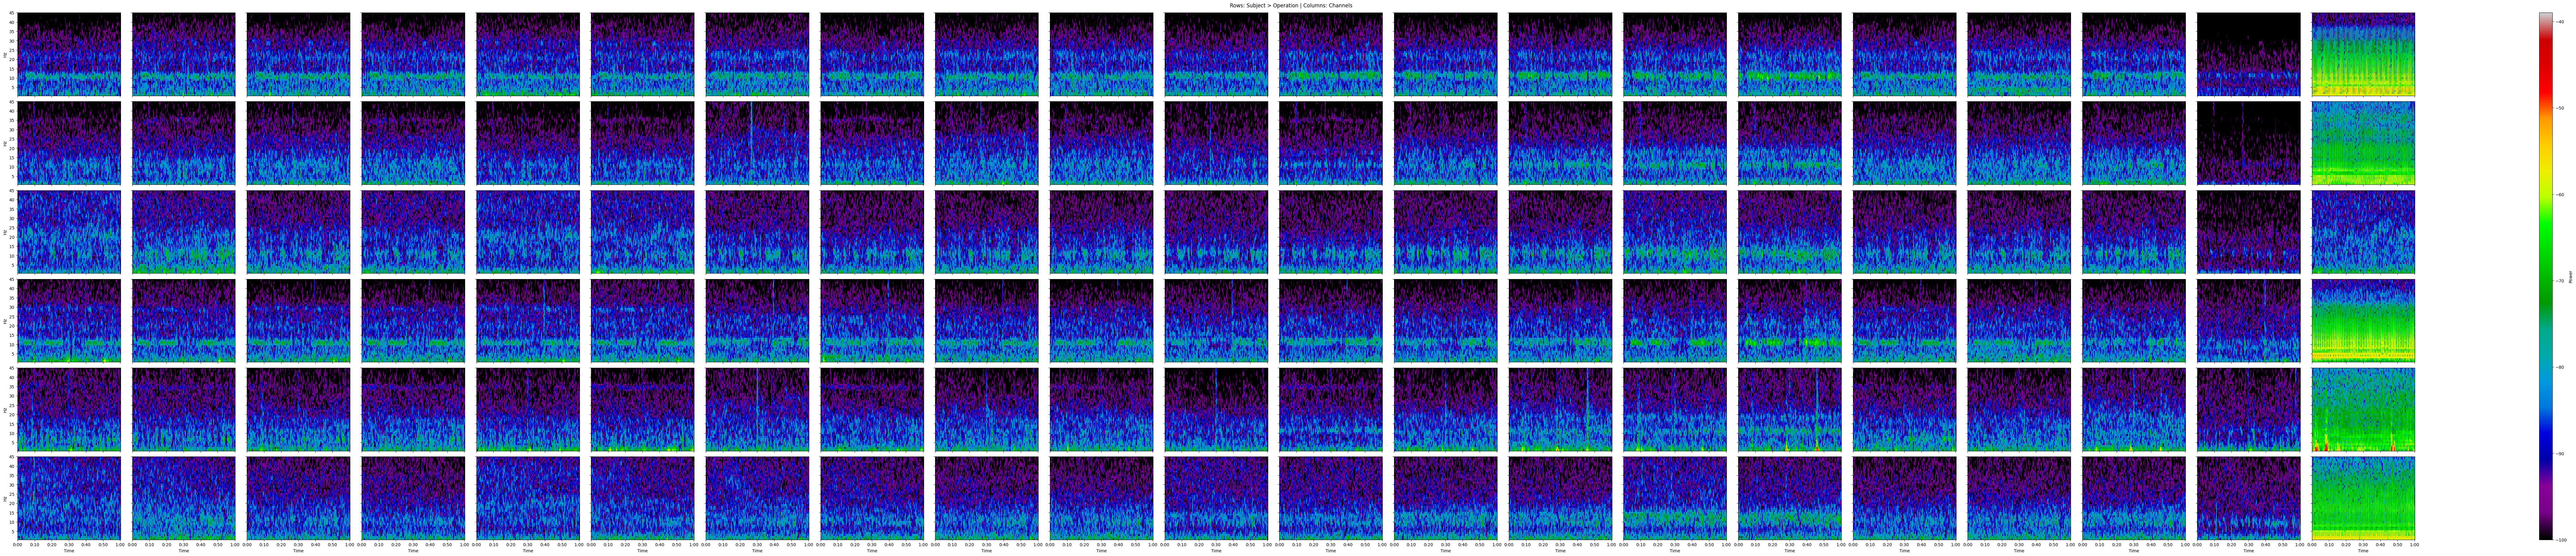

In [346]:
# Baseline   spectrograms (operation_id = 0)
# Arithmetic spectrograms (operation_id = 1)

print(f"dimensions: (subject, operation, channel, freqs, times)")
if True:
    fig, axes = multi_spectrogram(Sxx[0:3,:,:], [1,0], [2], sr, window_length, hop=hop,
                                cmap="nipy_spectral",
                                y_coords=freqs)
    for row in axes:
        row[0].set_ylim(0.5,45)

    fig.suptitle("Rows: Subject > Operation | Columns: Channels");

#### Normalization

In [347]:
Sxx.shape

(36, 2, 21, 45, 241)

In [348]:
if True:

    # Block scaling: Arithemtic
    # We remove the mean of every axis other than arithmetic
    # Specify the acis whose effects you would like to highlight
    mu    = np.nanmean(Sxx, axis=(1), keepdims=True)
    sigma = np.nanstd (Sxx, axis=(1), keepdims=True) + 1e-12
    print(f"mu.shape: {mu.shape}")

    # Mean-Centering
    Sxx = Sxx - mu
    # Autoscaling
    # Sxx = Sxx/sigma



mu.shape: (36, 1, 21, 45, 241)


In [349]:
mu.shape, Sxx.shape

((36, 1, 21, 45, 241), (36, 2, 21, 45, 241))

#### Unfold Tensor


rows: (subject $\times$ operation $\times$ time)

columns: (channel $\times$ freqs)


In [350]:
from mesa.fusion import unfold_2D

subjects = np.arange(36)+1
operations = np.arange(2)
channels = np.arange(21)+1

# Get a subset of subjects
# Sxx = Sxx[10:15]
# subjects = subjects[10:15]
# Subset of channels
Sxx = Sxx[:,:, 0:20]
channels = channels[0:20]

labels = [subjects, operations, channels, freqs, times]
label_names = ["subjects", "operations", "channels", "freq", "time"]
X_unfold, labels_unfold, label_names = unfold_2D(Sxx,rows=[1,4], cols=[0,2,3], labels=labels, label_names=label_names)

X_unfold.shape

(482, 32400)

In [351]:
len(labels_unfold), len(labels_unfold[0]), len(labels_unfold[1]), label_names[0], label_names[1]

(2, 2, 3, ['operations', 'time'], ['subjects', 'channels', 'freq'])

#### Save .mat file

In [352]:
from scipy.io import savemat

savemat(
    "EEG.mat", {"data": X_unfold,
                    "label_names": label_names,
                    "obs_l": np.array(labels_unfold[0], dtype=object),
                    "var_l": np.array(labels_unfold[1], dtype=object)}
)